In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns

data = pd.read_csv(r'C:\Users\user\Desktop\practice\conversion.csv')
data.head()

,ad_id,xyz_campaign_id,fb_campaign_id,age,gender,interest,Impressions,Clicks,Spent,Total_Conversion,Approved_Conversion
0,708746,916,103916,30-34,M,15,7350,1,1.43,2,1
1,708749,916,103917,30-34,M,16,17861,2,1.82,2,0
2,708771,916,103920,30-34,M,20,693,0,0.00,1,0
3,708815,916,103928,30-34,M,28,4259,1,1.25,1,0
4,708818,916,103928,30-34,M,28,4133,1,1.29,1,1


In [9]:
data.shape # кол-во строк и столбцов

(1143, 11)

In [10]:
data.dtypes # смотрим типы данных

ad_id                    int64
xyz_campaign_id          int64
fb_campaign_id           int64
age                        str
gender                     str
interest                 int64
Impressions              int64
Clicks                   int64
Spent                  float64
Total_Conversion         int64
Approved_Conversion      int64
dtype: object

In [11]:
data.isna().sum() # проверяем данные на наличие пропущенных значений

ad_id                  0
xyz_campaign_id        0
fb_campaign_id         0
age                    0
gender                 0
interest               0
Impressions            0
Clicks                 0
Spent                  0
Total_Conversion       0
Approved_Conversion    0
dtype: int64

In [12]:
data.xyz_campaign_id.unique() # определяем уникальные рекламные кампании в базе X

array([ 916,  936, 1178])

<Axes: xlabel='Impressions', ylabel='Count'>

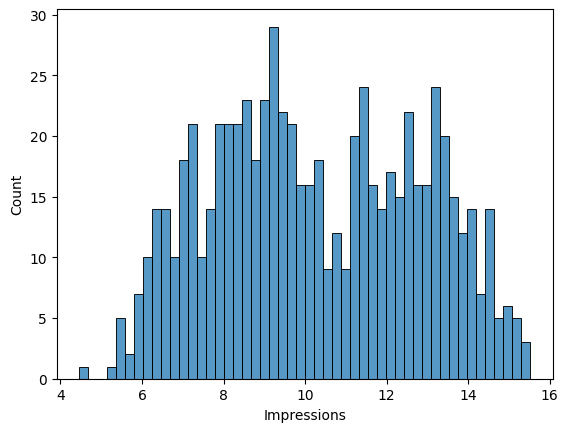

In [ ]:
sns.histplot(np.log(data.groupby('fb_campaign_id').Impressions.sum()), 
             kde = False,
             bins = 50) # график распределения числа показов для рекламных кампаний в Facebook с прологарифмированными значениями

In [20]:
data_grouped = data.groupby(['xyz_campaign_id', 'fb_campaign_id'], as_index=False).Impressions.sum()
data_grouped['Impressions'] = np.log(data_grouped['Impressions'])
data_grouped['xyz_campaign_id'] = data_grouped['xyz_campaign_id'].astype('str')
data_grouped

,xyz_campaign_id,fb_campaign_id,Impressions
0,916,103916,8.902456
1,916,103917,9.790375
2,916,103920,6.541030
3,916,103928,9.035034
4,916,103929,7.557473
...,...,...,...
686,1178,179977,13.937527
687,1178,179978,13.365386
688,1178,179979,11.928546
689,1178,179981,13.580108


<Axes: xlabel='Impressions', ylabel='Count'>

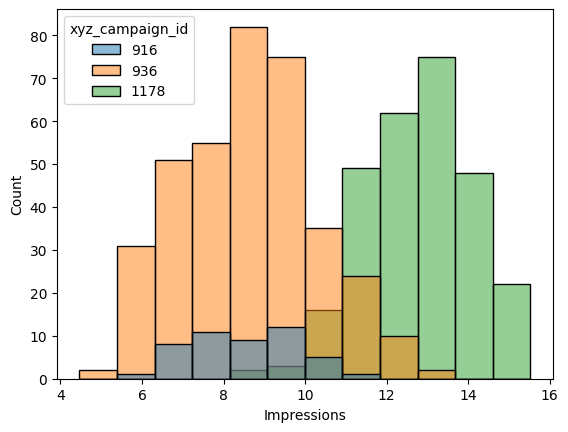

In [21]:
sns.histplot(data=data_grouped, x='Impressions', hue='xyz_campaign_id')